=== PLOTTING ELECTRON GRAPHS ===


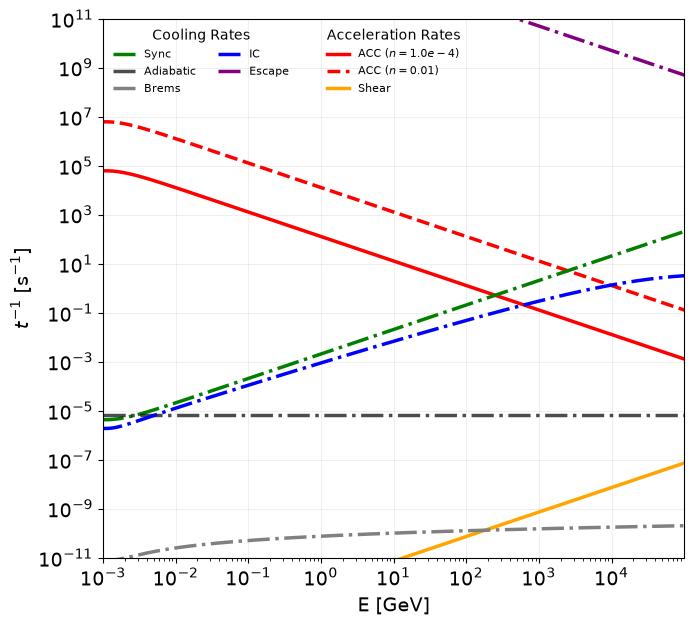

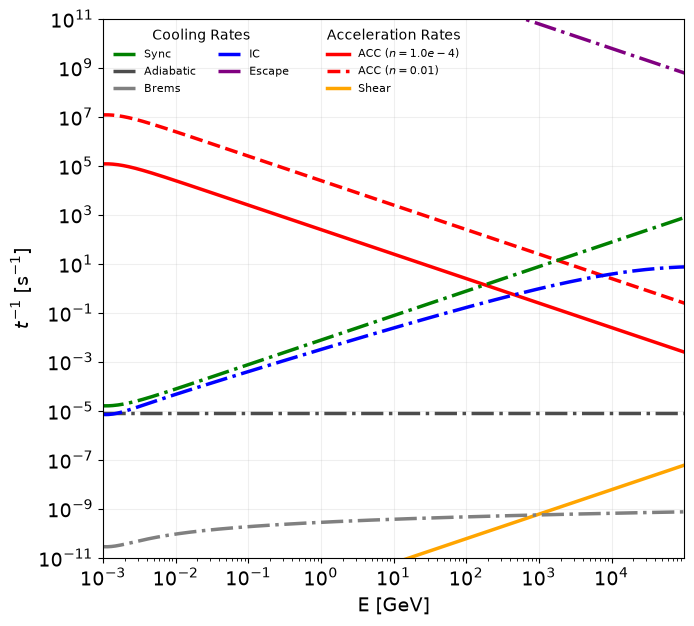

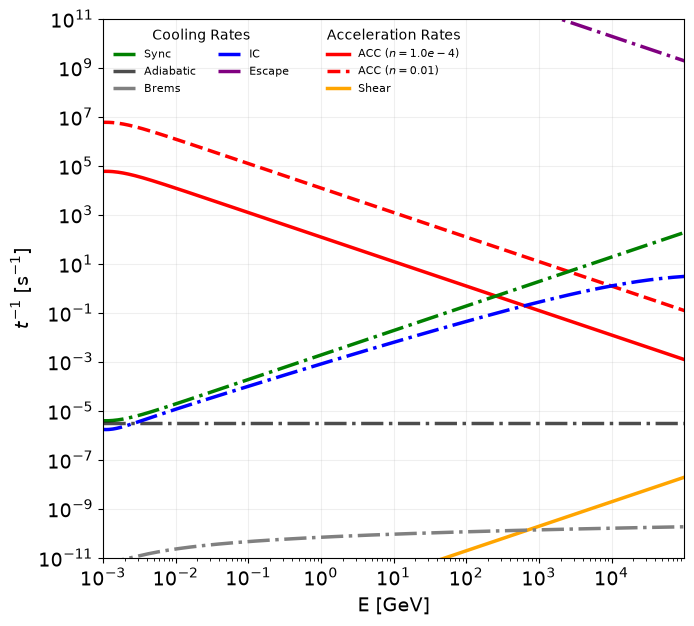

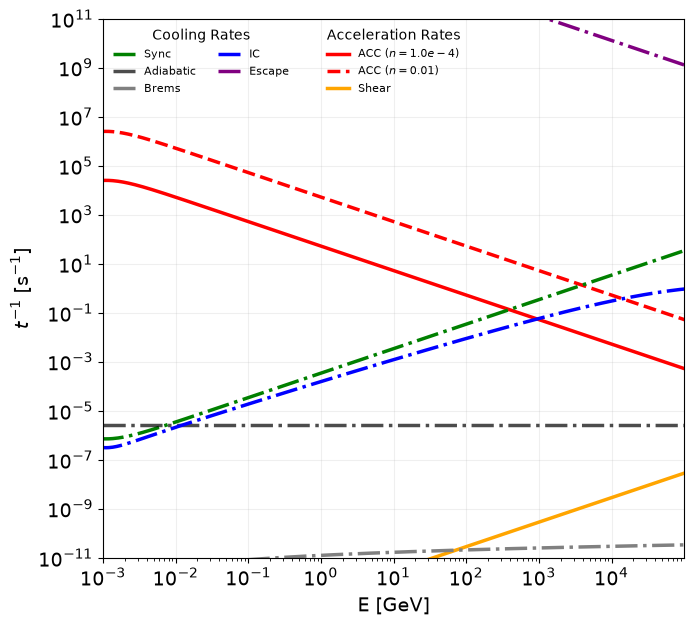

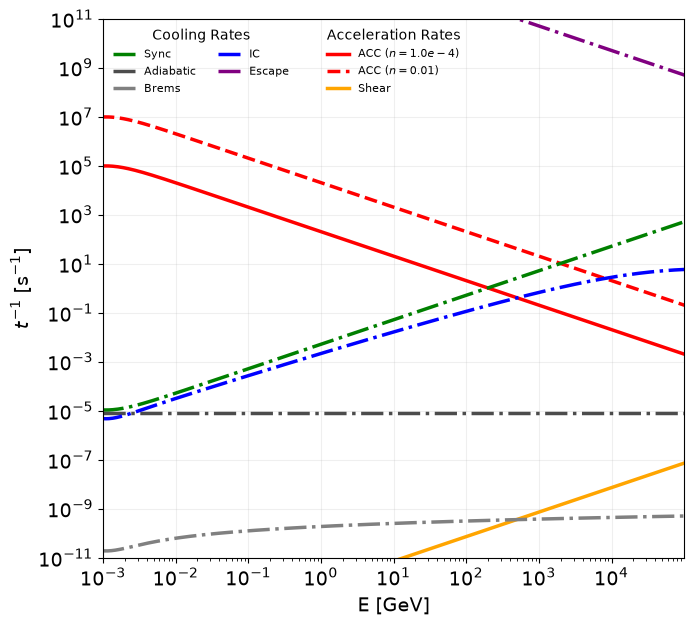

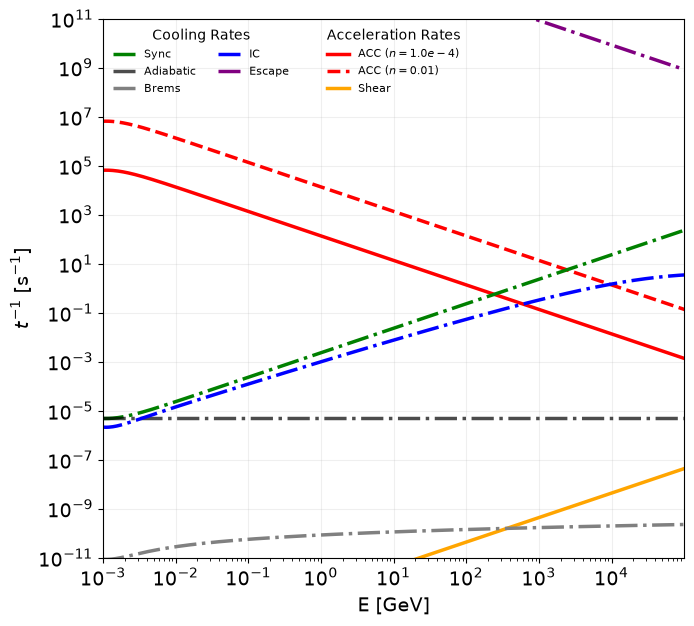

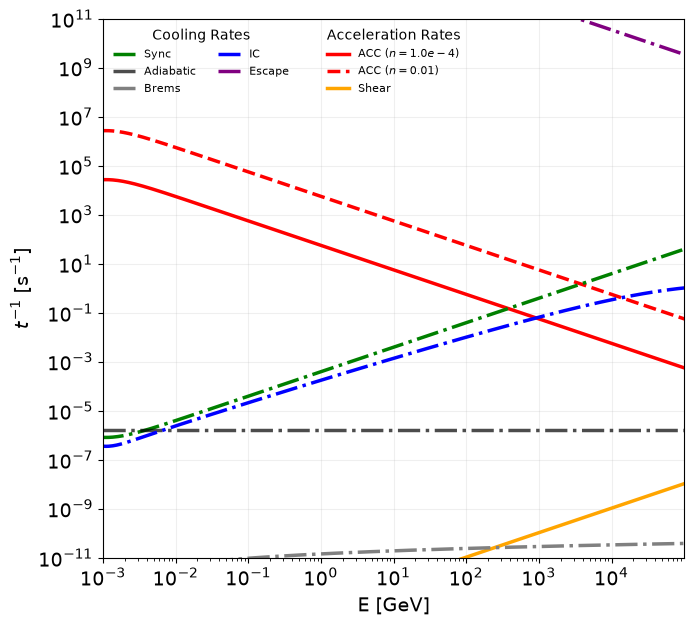

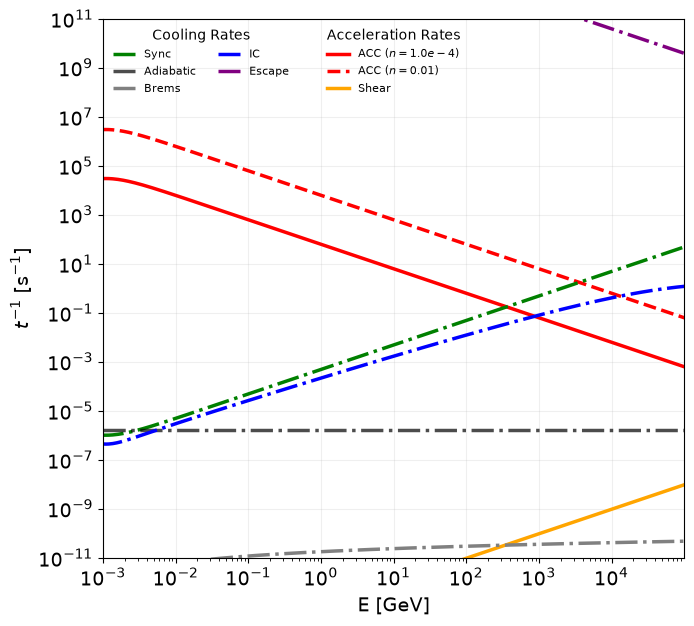

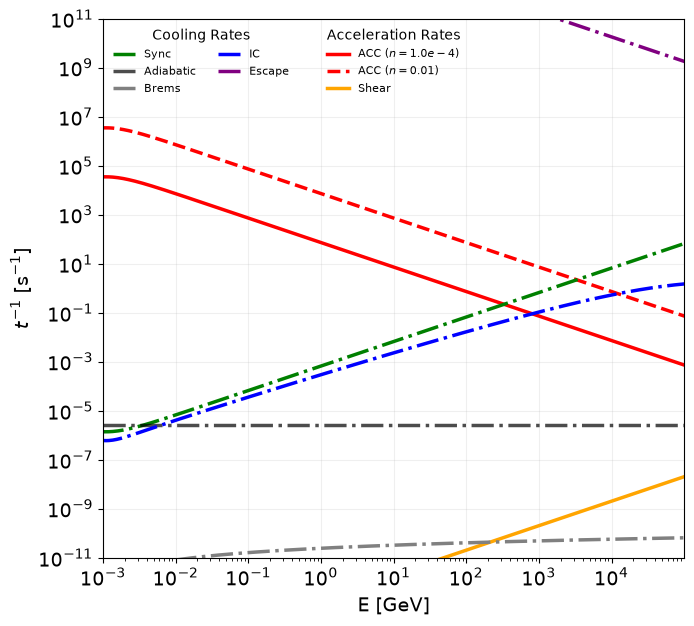

=== PLOTTING OXYGEN GRAPHS ===


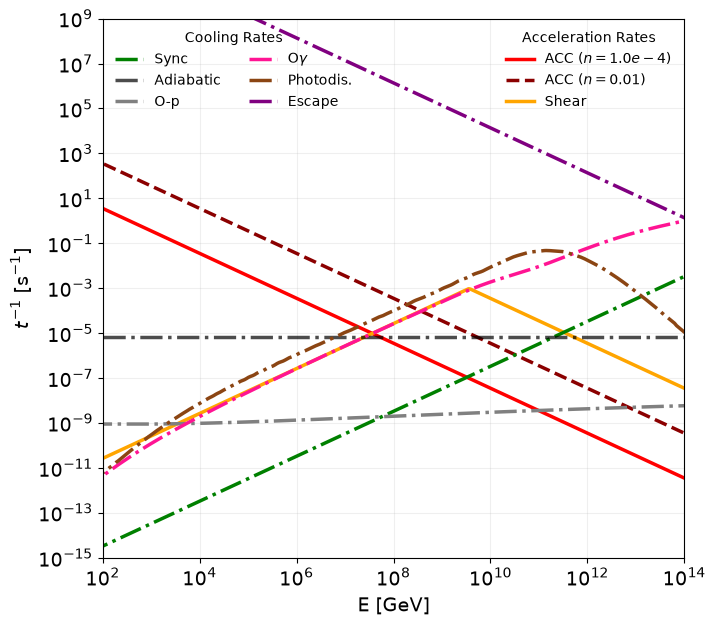

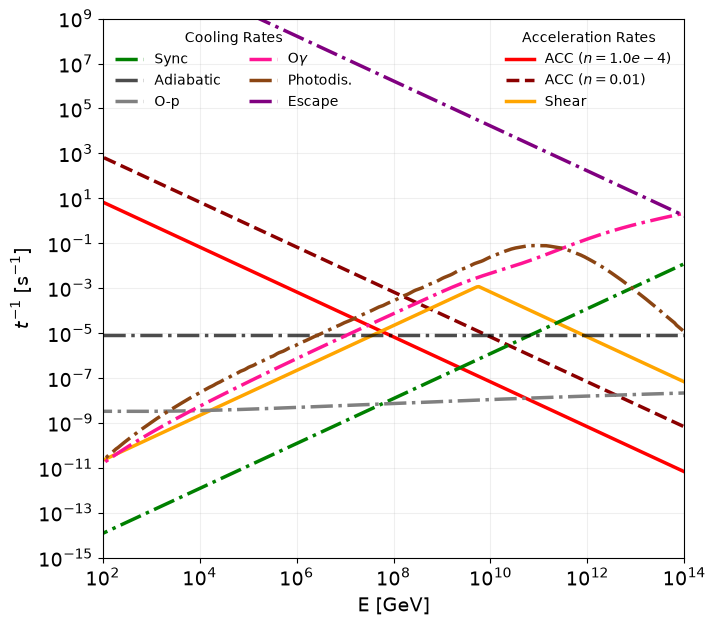

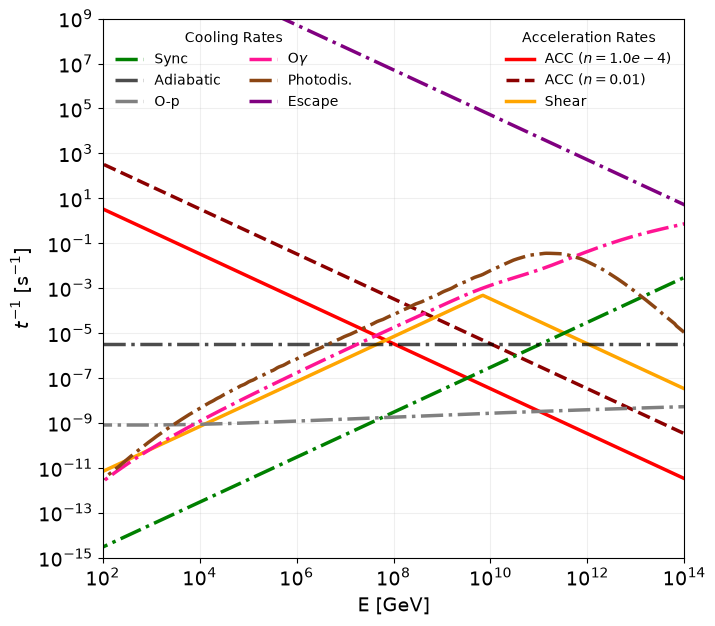

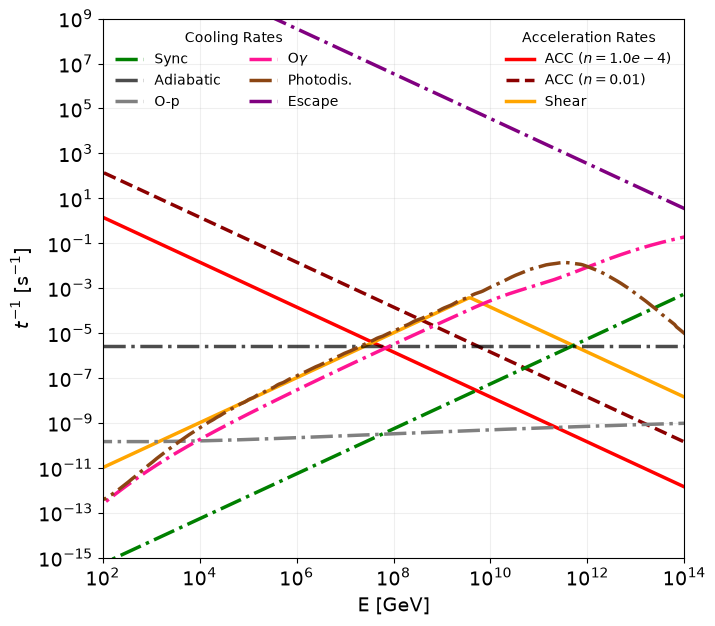

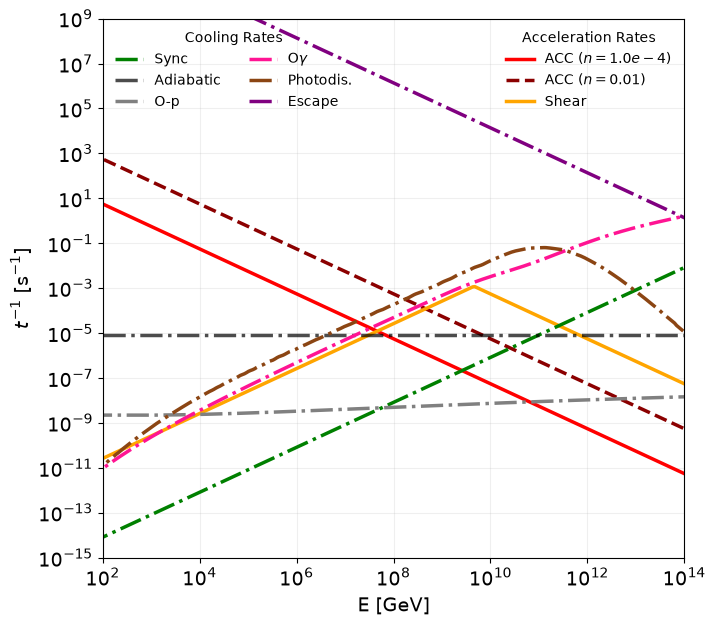

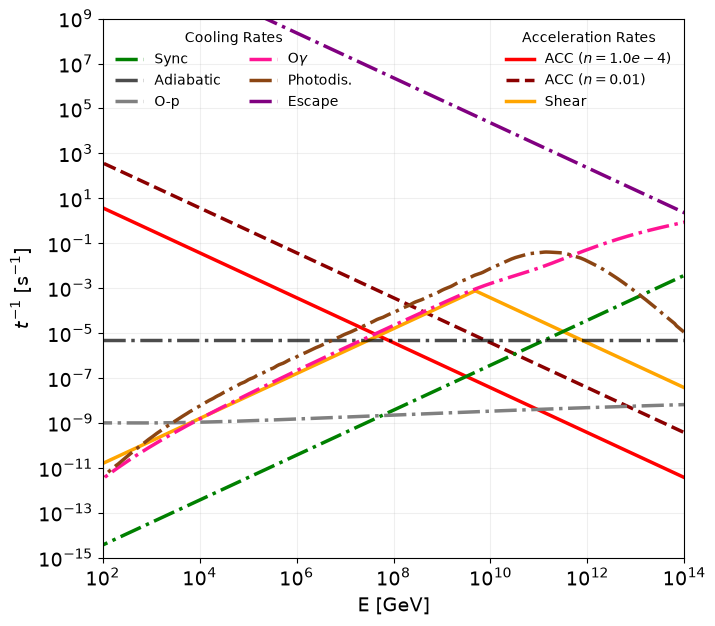

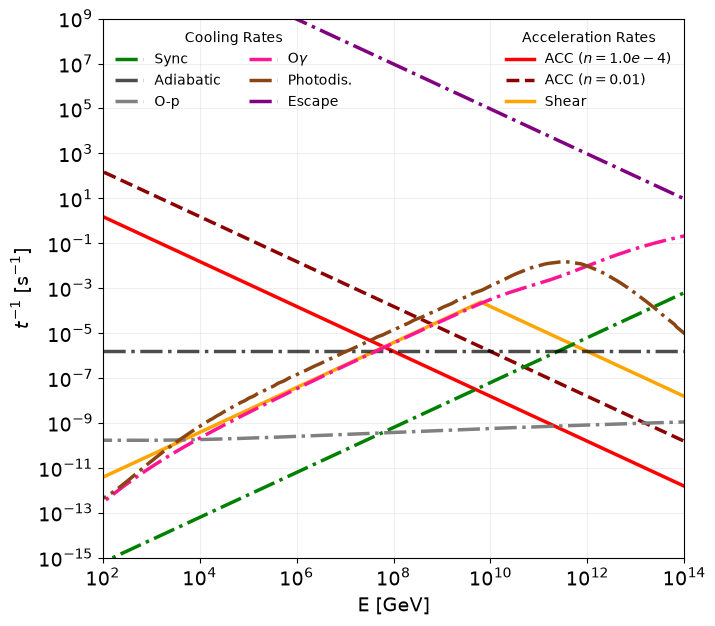

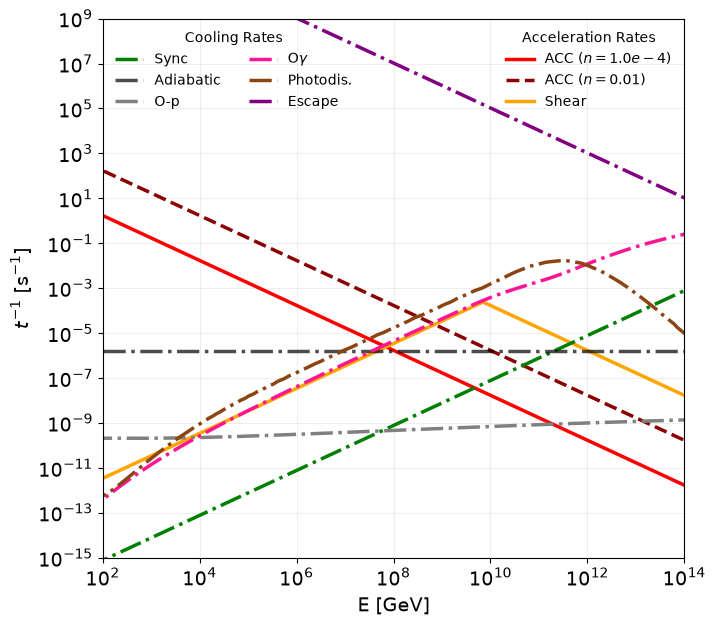

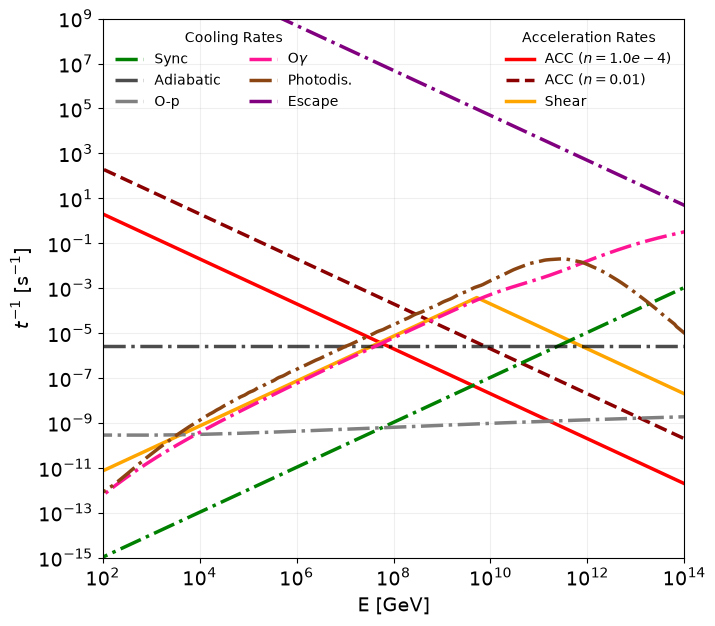

In [1]:
print("=== PLOTTING ELECTRON GRAPHS ===")
import csv
import matplotlib.pyplot as plt
import os

# --- Pastas de entrada (ajuste aqui se o run_pipeline salvou em outro lugar) ---
ELECTRON_DIR = "data2_oxygen"        # pasta com {name}_electrons.csv
OXYGEN_DIR   = "data2_oxygen" # pasta com {name}_oxygen.csv (saida do run_pipeline p/ source.txt)

source_file = "source2.txt"
source_list = []

try:
    with open(source_file, mode='r') as csvfile:
        reader = csv.DictReader(csvfile)
        for row in reader:
            source_list.append(row)
except FileNotFoundError:
    print(f"ERROR: File '{source_file}' not found.")

for params in source_list:
    source_name = params['name']
    filename = f"{ELECTRON_DIR}/{source_name}_electrons.csv"

    # 1. Resgatando os valores de n do seu source.txt
    n_val = params.get('n', 'N/A')
    n_2_val = params.get('n_2', 'N/A')

    E_GeV_ele, rate_acc, rate_acc_2, rate_sync, rate_bremss, rate_ic0, rate_ic1 = [], [], [], [], [], [], []
    rate_shear_ele, rate_esc_ele = [], []
    t_ad_val = 0

    try:
        with open(filename, 'r') as f:
            reader = csv.DictReader(f)
            for row in reader:
                E_GeV_ele.append(float(row['E_GeV']))
                rate_acc.append(float(row['rate_acc']))
                rate_acc_2.append(float(row['rate_acc_2']))
                rate_sync.append(float(row['rate_sync']))
                rate_bremss.append(float(row['rate_bremss']))
                rate_ic0.append(float(row['rate_ic_0']))
                rate_ic1.append(float(row['rate_ic_1']))
                rate_shear_ele.append(float(row['Shear']))
                rate_esc_ele.append(float(row['ESC']))
                t_ad_val = float(row['t_ad_val'])
    except FileNotFoundError:
        print(f"ERROR: File '{filename}' not found.")
        continue

    plt.figure(figsize=(7.5, 7))

    # 2. Inserindo os valores dinamicamente nas labels usando f-strings
    line_acc, = plt.loglog(E_GeV_ele, rate_acc, label=f'ACC ($n={n_val}$)', color='red', linestyle='-', linewidth=2.5)
    line_acc2, = plt.loglog(E_GeV_ele, rate_acc_2, label=f'ACC ($n={n_2_val}$)', color='red', linestyle='--', linewidth=2.5)

    line_shear, = plt.loglog(E_GeV_ele, rate_shear_ele, label='Shear', color='orange', linestyle='-', linewidth=2.5)

    # Curvas de Resfriamento/Fuga
    line_sync, = plt.loglog(E_GeV_ele, rate_sync, label='Sync', color='green', linestyle='dashdot', linewidth=2.5)
    line_ad = plt.axhline(y=t_ad_val, label='Adiabatic', color='black', linestyle='dashdot', alpha=0.7, linewidth=2.5)
    line_brems, = plt.loglog(E_GeV_ele, rate_bremss, label='Brems', color='grey', linestyle='dashdot', linewidth=2.5)
    line_ic1, = plt.loglog(E_GeV_ele, rate_ic1, label='IC', color='blue', linestyle='dashdot', markerfacecolor='none', linewidth=2.5)
    line_esc, = plt.loglog(E_GeV_ele, rate_esc_ele, label='Escape', color='purple', linestyle='dashdot', linewidth=2.5)

    leg_acc = plt.legend(handles=[line_acc, line_acc2, line_shear], title='Acceleration Rates', loc='upper center', fontsize=8, frameon=False)
    plt.gca().add_artist(leg_acc)
    leg_cool = plt.legend(handles=[line_sync, line_ad, line_brems, line_ic1, line_esc], title='Cooling Rates', loc='upper left', fontsize=8, frameon=False, ncol=2)

    plt.xlabel('E [GeV]', fontsize=14)
    plt.ylabel('$t^{-1}$ [s$^{-1}$]', fontsize=14)
    plt.xlim(1e-3, 1e5)
    plt.ylim(1e-11, 1e11)

    plt.xticks([10.0**i for i in range(-3, 5, 1)])
    plt.yticks([10.0**i for i in range(-11, 12, 2)])
    plt.tick_params(axis='both', which='major', labelsize=14)

    plt.grid(True, which="major", ls="-", alpha=0.2)

    os.makedirs("image", exist_ok=True)

    plt.savefig(f"image/{source_name}_electrons.png", bbox_inches='tight')

    plt.show()

print("=== PLOTTING OXYGEN GRAPHS ===")
import csv
import matplotlib.pyplot as plt
import os

# Garante que a pasta existe para não dar erro no savefig
os.makedirs("image", exist_ok=True)

for params in source_list:
    source_name = params['name']
    filename = f"{OXYGEN_DIR}/{source_name}_oxygen.csv"

    # 1. Resgatando os valores de n para as legendas
    n_val = params.get('n', 'N/A')
    n_2_val = params.get('n_2', 'N/A')

    # 2. Listas para os núcleos de oxigênio (substitui as listas de prótons)
    E_GeV_O, rate_acc_O, rate_acc_O_2, rate_sync_O = [], [], [], []
    rate_Op, rate_pg, rate_photodis = [], [], []
    rate_shear_O, rate_esc_O = [], []
    t_ad_val = 0

    try:
        with open(filename, 'r') as f:
            reader = csv.DictReader(f)
            for row in reader:
                E_GeV_O.append(float(row['E_prime_GeV_total']))
                rate_acc_O.append(float(row['rate_acc']))
                rate_acc_O_2.append(float(row['rate_acc_2']))
                rate_sync_O.append(float(row['rate_sync']))
                rate_Op.append(float(row['rate_Op']))
                rate_pg.append(float(row['rate_pg']))
                rate_photodis.append(float(row['rate_photodisintegration']))
                rate_shear_O.append(float(row['Shear']))
                rate_esc_O.append(float(row['ESC']))
                t_ad_val = float(row['t_ad_val'])

        plt.figure(figsize=(7.5, 7))

        # 3. Curvas de Aceleração (Original e Alternativa) com f-strings
        line_acc, = plt.loglog(E_GeV_O, rate_acc_O, label=f'ACC ($n={n_val}$)', color='red', linestyle='-', linewidth=2.5)
        line_acc2, = plt.loglog(E_GeV_O, rate_acc_O_2, label=f'ACC ($n={n_2_val}$)', color='darkred', linestyle='--', linewidth=2.5)
        line_shear, = plt.loglog(E_GeV_O, rate_shear_O, label='Shear', color='orange', linestyle='-', linewidth=2.5)

        # Curvas de Resfriamento/Fuga (agora para oxigênio)
        line_sync, = plt.loglog(E_GeV_O, rate_sync_O, label='Sync', color='green', linestyle='-.', linewidth=2.5)
        line_ad = plt.axhline(y=t_ad_val, label='Adiabatic', color='black', linestyle='-.', alpha=0.7, linewidth=2.5)
        line_Op, = plt.loglog(E_GeV_O, rate_Op, label='O-p', color='grey', linestyle='-.', linewidth=2.5)
        line_pg, = plt.loglog(E_GeV_O, rate_pg, label='O$\\gamma$', color='deeppink', linestyle='-.', linewidth=2.5)
        line_photodis, = plt.loglog(E_GeV_O, rate_photodis, label='Photodis.', color='saddlebrown', linestyle='-.', linewidth=2.5)
        line_esc, = plt.loglog(E_GeV_O, rate_esc_O, label='Escape', color='purple', linestyle='-.', linewidth=2.5)

        # 4. Atualização da legenda de aceleração
        leg_acc = plt.legend(handles=[line_acc, line_acc2, line_shear], title='Acceleration Rates', loc='upper right', fontsize=10, frameon=False)
        plt.gca().add_artist(leg_acc)
        leg_cool = plt.legend(handles=[line_sync, line_ad, line_Op, line_pg, line_photodis, line_esc], title='Cooling Rates', loc='upper left', fontsize=10, frameon=False, ncol=2)

        plt.xlabel('E [GeV]', fontsize=14)
        plt.ylabel('$t^{-1}$ [s$^{-1}$]', fontsize=14)
        # OBS: a grade de energia do oxigênio (E_GeV_O = logspace(0, 21, 500))
        # cobre uma faixa MUITO maior que a dos prótons antigos (era 1e2-1e10).
        # Ajuste xlim/ylim abaixo depois de olhar seus dados reais.
        plt.xlim(1e2, 1e14)
        plt.ylim(1e-15, 1e9)

        plt.xticks([10.0**i for i in range(2, 15, 2)])
        plt.yticks([10.0**i for i in range(-15, 10, 2)])
        plt.tick_params(axis='both', which='major', labelsize=14)

        plt.grid(True, which="major", ls="-", alpha=0.2)

        plt.savefig(f"image/{source_name}_oxygen.png", bbox_inches='tight')
        plt.show()

    except FileNotFoundError:
        print(f"File {filename} not found for plotting.")

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import csv
import os

# Directory settings and constants
source_file = "source2.txt"
output_dir = "data2_oxygen"
c = 2.998e10

with open(source_file, mode='r') as csvfile:
    reader = csv.DictReader(csvfile)
    
    for row in reader:
        source_name = row['name']
        Gamma_b = float(row['Gamma_b'])
        
        E_file = f"{output_dir}/{source_name}_oxygen_E_grid.npy"
        z_file = f"{output_dir}/{source_name}_oxygen_z_grid.npy"
        N_file = f"{output_dir}/{source_name}_oxygen_N_grid.npy"
        
        # Checks if the source files exist
        if not (os.path.exists(E_file) and os.path.exists(z_file) and os.path.exists(N_file)):
            print(f"Files not found for source: {source_name}. Skipping...")
            continue
            
        print(f"Generating plot for source: {source_name} (Gamma_b = {Gamma_b})")
        
        # Loads the data
        E_grid = np.load(E_file)
        z_grid = np.load(z_file)
        N_grid = np.load(N_file)
        
        # Converts Length Scale (z) to Time (t)
        beta = np.sqrt(1 - 1/Gamma_b**2)
        v_b = beta * c
        time_grid = z_grid / v_b
        
        # Creates 2D meshes
        E_mesh, T_mesh = np.meshgrid(E_grid, time_grid, indexing='ij')
        _, Z_mesh = np.meshgrid(E_grid, z_grid, indexing='ij')
        
        fig = plt.figure(figsize=(10, 7))
        
        # Adjusts the subplot margins to make room for the colorbar on the right
        fig.subplots_adjust(left=0.05, right=0.85)
        
        ax = fig.add_subplot(111, projection='3d')
        
        # AXES DEFINITION:
        X = np.log10(E_mesh)   # X-axis = Log(Energy)
        Y = T_mesh             # Y-axis = Time
        Z = Z_mesh             # Z-axis = Length Scale
        
        # Applies Density (N_grid) as the surface COLOR
        N_log = np.log10(N_grid + 1e-300)
        norm = plt.Normalize(N_log.min(), N_log.max())
        colors = cm.viridis(norm(N_log))
        
        # Plots the surface
        surf = ax.plot_surface(X, Y, Z, facecolors=colors, edgecolor='none', shade=False, alpha=0.9)
        
        # Labels
        ax.set_xlabel('Log(Energy) [erg]', labelpad=10)
        ax.set_ylabel('Time [s]', labelpad=10)
        
        # Increased labelpad to push the label away from the tick numbers
        ax.set_zlabel('Length Scale (z) [cm]', labelpad=15)
        
        # Colorbar indicating what the colors represent (Density)
        m = cm.ScalarMappable(cmap='viridis', norm=norm)
        m.set_array([])
        
        # Added pad=0.15 to push the colorbar further to the right, away from the Z-axis
        fig.colorbar(m, ax=ax, shrink=0.5, aspect=10, pad=0.15, label='Log(Density $N$)')
        
        # Title removed as requested
        
# Substitua o plt.show() por:
        
        # Define o caminho e o nome do arquivo da imagem
        image_filename = f"image/{source_name}_3Dplot.png"
        
        # Salva a imagem com alta resolução (dpi=300) e ajusta as margens (bbox_inches='tight')
        plt.savefig(image_filename, dpi=300, bbox_inches='tight')
        
        print(f"Imagem salva em: {image_filename}")
        
        # Fecha a figura para liberar a memória (muito importante ao rodar várias fontes em loop)
        plt.close(fig)

Generating plot for source: SDSS J010852.48-003919.4 (Gamma_b = 3.0)
Imagem salva em: image/SDSS J010852.48-003919.4_3Dplot.png
Generating plot for source: SDSS J011204.61-001442.4 (Gamma_b = 3.0)
Imagem salva em: image/SDSS J011204.61-001442.4_3Dplot.png
Generating plot for source: SDSS J011515.78+001248.4 (Gamma_b = 3.0)
Imagem salva em: image/SDSS J011515.78+001248.4_3Dplot.png
Generating plot for source: SDSS J015127.10-083019.3 (Gamma_b = 3.0)
Imagem salva em: image/SDSS J015127.10-083019.3_3Dplot.png
Generating plot for source: SDSS J020835.81-083754.8 (Gamma_b = 3.0)
Imagem salva em: image/SDSS J020835.81-083754.8_3Dplot.png
Generating plot for source: SDSS J075354.98+130916.5 (Gamma_b = 3.0)
Imagem salva em: image/SDSS J075354.98+130916.5_3Dplot.png
Generating plot for source: SDSS J080716.58+145703.3 (Gamma_b = 3.0)
Imagem salva em: image/SDSS J080716.58+145703.3_3Dplot.png
Generating plot for source: SDSS J083158.49+562052.3 (Gamma_b = 3.0)
Imagem salva em: image/SDSS J083158

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.integrate as spi
from scipy.interpolate import interp1d
import warnings
import os

warnings.filterwarnings("ignore", category=spi.IntegrationWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ==========================================================================
# 1. CONSTANTES FÍSICAS
# ==========================================================================
c = 2.998e10                   
e = 4.803e-10                  
m_e = 9.109e-28                
m_p = 1.6726e-24               
eV_to_erg = 1.60218e-12        
mec2_erg = m_e * c**2          
sigma_T = 6.65e-25             
pc_to_cm = 3.086e18            

Z_O = 8                        # numero atomico do Oxigenio
A_O = 16                       # massa atomica do Oxigenio
m_O = A_O * m_p                # massa do nucleo (aprox., ignora defeito de massa ~0.8%)
q_O = Z_O * e 
# ==========================================================================
# 2. CONVERSÕES DE ESCALA
# ==========================================================================
def rate_to_length_pc(rate):
    if rate <= 0.0: return np.inf
    return (c / rate) / pc_to_cm

def time_to_length_pc(time_s):
    return (c * time_s) / pc_to_cm

# ==========================================================================
# 3. FÍSICA: PERDAS (Losses)
# ==========================================================================
def K_pairs(x_prime):
    if x_prime <= 2.0: return 0.0
    if x_prime < 1000:
        term_ln = np.log(x_prime - 1)
        brac = 1 + 0.3957*term_ln + 0.1*(term_ln**2) + 0.0078*(term_ln**3)
        return 4 * (m_e/m_p) * (1/x_prime) * brac
    ln_x, ln_2x = np.log(x_prime), np.log(2*x_prime)
    num = -8.78 + 5.513*ln_x - 1.612*(ln_x**2) + 0.668*(ln_x**3)
    den = 3.1111*ln_2x - 8.0741
    return 4 * (m_e/m_p) * (1/x_prime) * (num/den)

def sigma_pairs(x_prime, Z=Z_O):
    if x_prime < 4.0:
        eta = (x_prime - 2)/(x_prime + 2)
        series = 1 + 0.5*eta + (23/40)*(eta**2) + (37/120)*(eta**3) + (61/192)*(eta**4)
        base = 1.2135e-27 * ((x_prime - 2)/2)**3 * series
    else:
        ln_2x = np.log(2*x_prime)
        term1 = 3.1111*ln_2x - 8.0741
        term2 = (2/x_prime)**2 * (2.7101*ln_2x - (ln_2x**2) + 0.6667*(ln_2x**3) + 0.5490)
        base = 5.7938e-28 * (term1 + term2)
    return (Z**2) * base

def get_sigma_K_pion(x_prime, A=A_O):
    if x_prime < 284: return 0.0
    K_pi = 9.78e-3 * (x_prime**0.4756)
    if 284 <= x_prime < 644: sigma_pi = 5.48e-28 * (x_prime/644)**2.60
    elif 644 <= x_prime < 978: sigma_pi = 5.48e-28 * (x_prime/644)**(-2.89)
    elif 978 <= x_prime < 1370: sigma_pi = 1.64e-28 * (x_prime/978)**1.51
    elif 1370 <= x_prime < 2387: sigma_pi = 2.73e-28 * (x_prime/1370)**(-1.20)
    else: sigma_pi = 1.4e-27 * 0.5 
    return (A**0.9) * sigma_pi * K_pi

def t_bh_rate_oxygen(E_O_erg, n_ph_func, c, m_nucleus, Z, E_ph_min_erg=None, E_ph_max_erg=None):
    gamma_O = E_O_erg / (m_nucleus * c**2)
    lower = max((2.0 * mec2_erg) / (2.0 * gamma_O), E_ph_min_erg) if E_ph_min_erg else (2.0 * mec2_erg) / (2.0 * gamma_O)
    upper = E_ph_max_erg or 1.0e8 * eV_to_erg
    if lower >= upper: return 1e-30

    def integrando_interno(epsilon_r):
        x_prime = epsilon_r / mec2_erg
        return (sigma_pairs(x_prime, Z) * K_pairs(x_prime)) * epsilon_r

    def integrando_externo(E_ph_erg):
        n_density = n_ph_func(E_ph_erg)
        if n_density <= 0.0: return 0.0
        epsilon_max = 2.0 * gamma_O * E_ph_erg
        if epsilon_max <= 2.0 * mec2_erg: return 0.0
        val_interna, _ = spi.quad(integrando_interno, 2.0 * mec2_erg, epsilon_max, limit=50)
        return (n_density / E_ph_erg**2) * val_interna

    E_ph_grid = np.logspace(np.log10(lower), np.log10(upper), 80)
    vals = np.array([integrando_externo(E_ph) for E_ph in E_ph_grid])
    rate = (c / (2.0 * gamma_O**2)) * np.trapz(vals * E_ph_grid, x=np.log(E_ph_grid))
    return max(rate, 1e-30)

def t_ppp_rate_oxygen(E_O_erg, n_ph_func, c, m_nucleus, A, E_ph_min_erg=None, E_ph_max_erg=None):
    gamma_O = E_O_erg / (m_nucleus * c**2)
    lower = max((284.0 * mec2_erg) / (2.0 * gamma_O), E_ph_min_erg) if E_ph_min_erg else (284.0 * mec2_erg) / (2.0 * gamma_O)
    upper = E_ph_max_erg or 1.0e8 * eV_to_erg
    if lower >= upper: return 1e-30

    def integrando_interno(epsilon_r):
        x_prime = epsilon_r / mec2_erg
        return get_sigma_K_pion(x_prime, A) * epsilon_r

    def integrando_externo(E_ph_erg):
        n_density = n_ph_func(E_ph_erg)
        if n_density <= 0.0: return 0.0
        epsilon_max = 2.0 * gamma_O * E_ph_erg
        if epsilon_max <= 284.0 * mec2_erg: return 0.0
        pts = [284.0 * mec2_erg, 644.0 * mec2_erg, 978.0 * mec2_erg]
        pts = [p for p in pts if p < epsilon_max]
        val_interna, _ = spi.quad(integrando_interno, 284.0 * mec2_erg, epsilon_max, points=pts, limit=50)
        return (n_density / E_ph_erg**2) * val_interna

    E_ph_grid = np.logspace(np.log10(lower), np.log10(upper), 80)
    vals = np.array([integrando_externo(E_ph) for E_ph in E_ph_grid])
    rate = (c / (2.0 * gamma_O**2)) * np.trapz(vals * E_ph_grid, x=np.log(E_ph_grid))
    return max(rate, 1e-30)

def t_sync_rate_oxygen(B_prime, E_prime, c, sigma_T):
    rate = (4.0/3.0) * (sigma_T * B_prime**2 * E_prime) / (m_e**2 * c**3 * 8 * np.pi)
    # Corrigido para as constantes do Oxigênio
    return max(rate * (Z_O**4) * (m_e / m_O)**4, 1e-30)

# TALYS & Fotodesintegração REAIS para Oxigênio
def load_talys_oxygen_channels(data_dir="", Z_target=Z_O, N_target=A_O - Z_O):
    eps_path = os.path.join(data_dir, "eps.txt")
    xs_path = os.path.join(data_dir, "xs_pd_thin.txt")
    eps_data_MeV = np.loadtxt(eps_path)
    oxygen_channels = {}
    with open(xs_path, 'r') as f:
        for line in f:
            parts = line.split()
            if not parts: continue
            Z, N = int(parts[0]), int(parts[1])
            if Z == Z_target and N == N_target:
                ch_str = f"{int(parts[2]):06d}"
                xs_vals_cm2 = np.array([float(x) for x in parts[3:]]) * 1e-27
                mass_lost_amu = (int(ch_str[0]) * 1) + (int(ch_str[1]) * 1) + \
                                (int(ch_str[2]) * 2) + (int(ch_str[3]) * 3) + \
                                (int(ch_str[4]) * 3) + (int(ch_str[5]) * 4)
                interp_func = interp1d(eps_data_MeV, xs_vals_cm2, bounds_error=False, fill_value=0.0)
                oxygen_channels[ch_str] = {'mass_lost_amu': mass_lost_amu, 'interp': interp_func}
    return eps_data_MeV, oxygen_channels

def photodisintegration_rate(E_O_erg, n_ph_func, c, m_nucleus, eps_data_MeV, oxygen_channels, A=A_O):
    gamma_O = E_O_erg / (m_nucleus * c**2)
    eps_min_erg = eps_data_MeV[0] * 1e6 * eV_to_erg
    eps_max_erg = eps_data_MeV[-1] * 1e6 * eV_to_erg
    
    E_ph_min_lab = eps_min_erg / (2.0 * gamma_O)
    E_ph_max_lab = 1.0e8 * eV_to_erg
    
    if E_ph_min_lab >= E_ph_max_lab:
        return 1e-30
        
    E_ph_grid = np.logspace(np.log10(E_ph_min_lab), np.log10(E_ph_max_lab), 60)
    n_density_grid = np.array([n_ph_func(E) for E in E_ph_grid])
    expected_dE_dt_loss = 0.0
    
    for ch, data in oxygen_channels.items():
        sigma_interp = data['interp']
        fracao_perda = data['mass_lost_amu'] / A
        
        def integrando_externo(i, E_ph):
            n_den = n_density_grid[i]
            if n_den <= 0: return 0.0
            eps_r_max_erg = 2.0 * gamma_O * E_ph
            if eps_r_max_erg <= eps_min_erg: return 0.0
            eps_r_max_erg = min(eps_r_max_erg, eps_max_erg)
            
            eps_r_grid = np.logspace(np.log10(eps_min_erg), np.log10(eps_r_max_erg), 40)
            eps_r_MeV = eps_r_grid / (1e6 * eV_to_erg)
            sigma_vals_cm2 = sigma_interp(eps_r_MeV)
            int_interna = np.trapz(eps_r_grid * sigma_vals_cm2, x=eps_r_grid)
            return (n_den / E_ph**2) * int_interna
            
        vals_externos = np.array([integrando_externo(i, E) for i, E in enumerate(E_ph_grid)])
        rate_channel = (c / (2.0 * gamma_O**2)) * np.trapz(vals_externos, x=E_ph_grid)
        
        if rate_channel > 0:
            expected_dE_dt_loss += rate_channel * (fracao_perda * E_O_erg)
            
    return max(expected_dE_dt_loss / E_O_erg, 1e-30) if E_O_erg > 0 else 1e-30

# ==========================================================================
# 4. FÍSICA: ACELERAÇÃO E ESCAPE (Passos 3 e 4)
# ==========================================================================
def L_acc_fermi_I_pc(E_erg, q, B_prime, u_s_frac=0.1):
    u_s = u_s_frac * c
    t_acc = (20.0 / 3.0) * (E_erg * c) / (u_s**2 * q * B_prime)
    return time_to_length_pc(t_acc)

def L_acc_shear_pc(E_erg, Gamma_j, beta_j, delta_r, B_prime, q):
    delta_u = beta_j * c
    r_g = E_erg / (q * B_prime)
    rate = 1.0 / np.maximum((3.0 * (delta_r**2) * c) / ((Gamma_j**4) * (delta_u**2) * r_g), r_g / c)
    return rate_to_length_pc(rate)

def L_acc_min_pc(E_erg, q, B_prime):
    r_g = E_erg / (q * B_prime)
    return r_g / pc_to_cm

def L_esc_bohm_pc(E_erg, q, B_prime, delta_r):
    r_g = E_erg / (q * B_prime)
    t_esc = (1.5 * delta_r**2) / (r_g * c)
    return time_to_length_pc(t_esc)

def E_hillas_EeV(q, B_prime, delta_r):
    # Condição de confinamento (beta=1): R_larmor = delta_r => E_max = q * B * delta_r
    E_erg = q * B_prime * delta_r
    return E_erg / (1e18 * eV_to_erg)

# ==========================================================================
# 5. PIPELINE PRINCIPAL (Execução pelas Fontes)
# ==========================================================================
def main():
    # 1. Leitura do arquivo de parâmetros (sua tabela final com as fontes)
    csv_params = "data2_oxygen/all_calculated_parameters.csv"
    try:
        df = pd.read_csv(csv_params)
        print(f"Lidos {len(df)} registros de {csv_params}.")
    except Exception as e:
        print(f"Erro ao ler {csv_params}: {e}")
        return

    # 2. Configurações de diretórios
    photons_dir = "data2_oxygen" # Onde os fótons E as planilhas pré-calculadas estão salvos
    talys_dir = "" # Pasta que contém o eps.txt e xs_pd_thin.txt (garanta que seja para Oxigênio!)
    
    print(f"Carregando canais TALYS de '{talys_dir}'...")
    eps_data_MeV, oxygen_channels = load_talys_oxygen_channels(data_dir=talys_dir)
    
    if not oxygen_channels:
        print("AVISO: Nenhum canal para Oxigênio-16 encontrado no TALYS. PDI será ~0.")

    # 3. Preparação do Grid
    E_N_EeV_grid = np.logspace(-3, 4, 30) 
    E_N_erg_grid = E_N_EeV_grid * 1e18 * eV_to_erg

    out_img_dir = "fig7_plots/02"
    os.makedirs(out_img_dir, exist_ok=True)

    # 4. Loop Mestre para calcular todas as fontes
    for index, row in df.iterrows():
        source_name = row['Source_Name']
        print(f"\n--- Processando Fonte [{index+1}/{len(df)}]: {source_name} ---")
        
        # Extrair parâmetros vitais
        B_prime = row['B_prime_Gauss']
        delta_r = row['r_j_z0_cm']
        Gamma_b = row['Gamma_b']
        beta = row['beta']
        
        E_ph_min_val = (10.0 ** row['PH_Ei']) * eV_to_erg
        E_ph_max_val = (10.0 ** row['PH_Ef']) * eV_to_erg
        
        # ==================================================================
        # 4.1 Carregar o campo de fótons REAL
        # ==================================================================
        photon_file = os.path.join(photons_dir, f"{source_name}_photons.csv")
        if os.path.exists(photon_file):
            df_ph = pd.read_csv(photon_file)
            valid = df_ph['n_ph_density'] > 0
            log_E = np.log10(df_ph.loc[valid, 'E_ph_erg'])
            log_n = np.log10(df_ph.loc[valid, 'n_ph_density'])
            interp_n_ph = interp1d(log_E, log_n, bounds_error=False, fill_value=-100.0)
            
            def n_ph_func(E_ph):
                if E_ph <= 0: return 0.0
                log_val = interp_n_ph(np.log10(E_ph))
                return 10**log_val if log_val > -100 else 0.0
                
            print("  -> Campo de fótons numérico lido com sucesso.")
        else:
            print(f"  -> AVISO: {photon_file} ausente! Pulo de fonte.")
            continue
            
        # ==================================================================
        # 4.2 Carregar a tabela de Aceleração Pré-calculada (Pelas Colunas)
        # ==================================================================
        acc_file = os.path.join(photons_dir, f"{source_name}_oxygen.csv")
        interp_f1, interp_f2, interp_shear = None, None, None
        
        if os.path.exists(acc_file):
            try:
                df_acc = pd.read_csv(acc_file)
                
                # A coluna 0 está em GeV
                E_acc_GeV = df_acc.iloc[:, 0]
                
                # 1 GeV = 10^9 eV. Convertendo para erg:
                E_acc_erg = E_acc_GeV * 1e9 * eV_to_erg  
                
                val_f1 = df_acc.iloc[:, 1]  # 2ª Coluna (Fermi eta 1)
                val_f2 = df_acc.iloc[:, 2]  # 3ª Coluna (Fermi eta 2)
                val_sh = df_acc.iloc[:, 8]  # 9ª Coluna (Shear)
                
                # Criar interpolações log-log para mapear no seu grid contínuo
                valid_f1 = val_f1 > 0
                if valid_f1.any():
                    interp_f1 = interp1d(np.log10(E_acc_erg[valid_f1]), np.log10(val_f1[valid_f1]), bounds_error=False, fill_value=np.nan)
                    
                valid_f2 = val_f2 > 0
                if valid_f2.any():
                    interp_f2 = interp1d(np.log10(E_acc_erg[valid_f2]), np.log10(val_f2[valid_f2]), bounds_error=False, fill_value=np.nan)
                    
                valid_sh = val_sh > 0
                if valid_sh.any():
                    interp_shear = interp1d(np.log10(E_acc_erg[valid_sh]), np.log10(val_sh[valid_sh]), bounds_error=False, fill_value=np.nan)
                    
                print("  -> Tabela de aceleração (GeV) incorporada (Lendo colunas 2, 3 e 9).")
            except Exception as e:
                print(f"  -> AVISO: Erro ao ler a tabela {acc_file}: {e}")

        # ==================================================================
        # 4.3 Integração das Taxas e Construção das Curvas
        # ==================================================================
        L_BH, L_PPP, L_PDI, L_sync, L_loss_tot = [], [], [], [], []
        L_fermi_1, L_fermi_2, L_shear, L_min, L_esc = [], [], [], [], []
        
        print("  -> Calculando taxas de perdas e incorporando aceleração...")
        for E_erg in E_N_erg_grid:
            # 1. Perdas (Losses) - Usando Oxigênio
            r_bh = t_bh_rate_oxygen(E_erg, n_ph_func, c, m_O, Z_O, E_ph_min_val, E_ph_max_val)
            r_ppp = t_ppp_rate_oxygen(E_erg, n_ph_func, c, m_O, A_O, E_ph_min_val, E_ph_max_val)
            r_pdi = photodisintegration_rate(E_erg, n_ph_func, c, m_O, eps_data_MeV, oxygen_channels)
            r_sync = t_sync_rate_oxygen(B_prime, E_erg, c, sigma_T)
            
            r_tot = r_bh + r_ppp + r_pdi + r_sync
            L_loss_tot.append(rate_to_length_pc(r_tot))
            L_BH.append(rate_to_length_pc(r_bh))
            L_PPP.append(rate_to_length_pc(r_ppp))
            L_PDI.append(rate_to_length_pc(r_pdi))
            L_sync.append(rate_to_length_pc(r_sync))
            
            # ==========================================================
            # 2. Aceleração (Convertendo a taxa t^-1 para comprimento L)
            # ==========================================================
            log_E_erg = np.log10(E_erg)
            
            # Fermi-I (Eficiência 1)
            if interp_f1 is not None and not np.isnan(interp_f1(log_E_erg)):
                rate_f1 = 10**(interp_f1(log_E_erg))
                L_fermi_1.append(rate_to_length_pc(rate_f1))
            else:
                L_fermi_1.append(L_acc_fermi_I_pc(E_erg, q_O, B_prime, u_s_frac=0.1))
                
            # Fermi-I (Eficiência 2)
            if interp_f2 is not None and not np.isnan(interp_f2(log_E_erg)):
                rate_f2 = 10**(interp_f2(log_E_erg))
                L_fermi_2.append(rate_to_length_pc(rate_f2))
            else:
                L_fermi_2.append(L_acc_fermi_I_pc(E_erg, q_O, B_prime, u_s_frac=0.3))
                
            # Shear
            if interp_shear is not None and not np.isnan(interp_shear(log_E_erg)):
                rate_shear = 10**(interp_shear(log_E_erg))
                L_shear.append(rate_to_length_pc(rate_shear))
            else:
                L_shear.append(L_acc_shear_pc(E_erg, Gamma_b, beta, delta_r, B_prime, q_O))
                
            # 3. Limite mínimo e Escape
            L_min.append(L_acc_min_pc(E_erg, q_O, B_prime))
            L_esc.append(L_esc_bohm_pc(E_erg, q_O, B_prime, delta_r))
            
        # ==================================================================
        # 4.4 Renderização do Gráfico Final
        # ==================================================================
        plt.figure(figsize=(10, 7))
        
        plt.plot(E_N_EeV_grid, L_loss_tot, '-', color='steelblue', label=r'$L_{loss}$ (Total)', linewidth=2)
        plt.plot(E_N_EeV_grid, L_BH, '--', color='steelblue', label='- BH', alpha=0.8)
        plt.plot(E_N_EeV_grid, L_PPP, '-.', color='steelblue', label='- PPP', alpha=0.8)
        plt.plot(E_N_EeV_grid, L_PDI, ':', color='steelblue', label='- PDI', alpha=0.8)
        plt.plot(E_N_EeV_grid, L_sync, color='black', linestyle='--', label='- synch.', alpha=0.6)
        
        plt.plot(E_N_EeV_grid, L_fermi_1, '--', color='red', label=r'$L_{acc}$ ($\eta = 10^{-4} $)', linewidth=2)
        plt.plot(E_N_EeV_grid, L_fermi_2, ':', color='red', label=r'$L_{acc}$ ($\eta = 10^{-2}$)', linewidth=2.5)
        plt.plot(E_N_EeV_grid, L_shear, '-.', color='darkorange', label=r'$L_{acc}$ - Shear', linewidth=2)
        plt.plot(E_N_EeV_grid, L_min, '-', color='firebrick', label=r'$L_{acc}^{min} (\eta=1)$', linewidth=2)
        
        plt.plot(E_N_EeV_grid, L_esc, '-', color='forestgreen', label=r'$L_{esc}$', linewidth=2)
        EH_EeV = E_hillas_EeV(q_O, B_prime, delta_r)
        plt.axvspan(EH_EeV, max(E_N_EeV_grid)*10, color='gray', alpha=0.2, label='Hillas Region')
        
        plt.xscale('log')
        plt.yscale('log')
        plt.xlim(1e-3, 1e4)
        plt.ylim(1e-8, 1e4) 
        
        plt.xlabel(r'Oxygen Energy $E_N$ [EeV]', fontsize=14)
        plt.ylabel(r'Length Scale [pc]', fontsize=14)
        plt.grid(True, which="both", ls="--", alpha=0.3)
        plt.legend(loc='upper right', fontsize=10, ncol=2)
        plt.tight_layout()
        
        save_path = os.path.join(out_img_dir, f"Fig_{source_name}_oxygen.png")
        plt.savefig(save_path, dpi=150)
        print(f"  -> Gráfico salvo em {save_path}")
        plt.show()
        plt.close() # Limpa o gráfico da RAM após salvar

if __name__ == "__main__":
    main()

Lidos 104 registros de data2_oxygen/all_calculated_parameters.csv.
Carregando canais TALYS de ''...


FileNotFoundError: eps.txt not found.